---
## Assignment

For your assignment, you'll do exactly what this notebook did, but with a dataset you choose connected to the research gap you identified.

**Checklist:**
1. Load and inspect a published dataset
2. Explain where it comes from and why it matters to your research
3. Compute summary statistics (central tendency, spread, shape, counts)
4. Create 3+ visualizations that reveal something interesting (or nothing interesting at all, null results are perfectly valid!)
5. Write a short interpretation of what you found

**Useful code patterns from today to adapt:**
- `pd.read_excel()` / `pd.read_csv()` to load data
- `.describe()`, `.mean()`, `.std()`, `.value_counts()` for summary stats
- `plt.hist()`, `sns.heatmap()`, `plt.scatter()` for visualization
- `.isnull().sum()` and filtering with boolean conditions for cleanup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded ✓")

All libraries loaded ✓


## 1-2-3. Load, inspect, explain published dataset and compute summary statistics

This is a multidimensional dataset about cost of living for 5,000 cities across 50+ dimensions. The dataset is derived from [kaggle.com](https://www.kaggle.com/datasets/mvieira101/global-cost-of-living) but it was scraped and put together by the author from another source — data gathered by scraping [Numbeo's website](https://www.numbeo.com).

This is a high-dimensional dataset that requires some type of support to be analyzed in its entirety so that makes it relevant to my topic about high-dimensional data analysis supports.

In [ ]:
df = pd.read_csv("/content/cost-of-living_v2.csv")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 4956, Columns: 58


,city,country,x1,x2,x3,x4,x5,x6,x7,x8,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,110.36,742.54,557.52,2669.12,1731.08,22067.70,10971.90,2689.62,3.47,1
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,123.51,1091.93,569.88,2952.70,1561.59,17746.11,9416.35,1419.87,5.03,1
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,43.89,533.28,317.45,1242.24,688.05,12892.82,5427.45,1211.68,5.19,1
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,41.17,522.40,294.05,1411.12,699.80,6092.45,2777.51,640.81,7.96,1
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,36.50,229.84,135.31,601.02,329.15,2506.73,1036.74,586.46,8.06,1


In [ ]:
column_mapping = {
    'meal_inexpensive_restaurant': 'x1',
    'meal_for_2_midrange_restaurant': 'x2',
    'mcmeal_mcdonalds': 'x3',
    'domestic_beer_0_5L_draught': 'x4',
    'imported_beer_0_33L': 'x5',
    'cappuccino': 'x6',
    'coke_pepsi_0_33L': 'x7',
    'water_0_33L': 'x8',
    'milk_1L': 'x9',
    'bread_500g': 'x10',
    'rice_1kg': 'x11',
    'eggs_12': 'x12',
    'cheese_1kg': 'x13',
    'chicken_1kg': 'x14',
    'beef_1kg': 'x15',
    'apples_1kg': 'x16',
    'banana_1kg': 'x17',
    'oranges_1kg': 'x18',
    'tomato_1kg': 'x19',
    'potato_1kg': 'x20',
    'onion_1kg': 'x21',
    'lettuce_1head': 'x22',
    'water_1_5L': 'x23',
    'wine_midrange': 'x24',
    'domestic_beer_0_5L_bottle': 'x25',
    'imported_beer_0_33L_bottle': 'x26',
    'cigarettes_20pack': 'x27',
    'one_way_ticket_transport': 'x28',
    'monthly_pass_transport': 'x29',
    'taxi_start': 'x30',
    'taxi_1km': 'x31',
    'taxi_1hr_waiting': 'x32',
    'gasoline_1L': 'x33',
    'volkswagen_golf': 'x34',
    'toyota_corolla': 'x35',
    'utilities_85m2_apt': 'x36',
    'mobile_prepaid_1min': 'x37',
    'internet_60mbps': 'x38',
    'fitness_club_monthly': 'x39',
    'tennis_court_1hr_weekend': 'x40',
    'cinema_ticket': 'x41',
    'preschool_monthly': 'x42',
    'international_school_yearly': 'x43',
    'jeans': 'x44',
    'summer_dress': 'x45',
    'nike_shoes': 'x46',
    'leather_shoes': 'x47',
    'apt_1br_city_centre_rent': 'x48',
    'apt_1br_outside_centre_rent': 'x49',
    'apt_3br_city_centre_rent': 'x50',
    'apt_3br_outside_centre_rent': 'x51',
    'apt_city_centre_price_sqm': 'x52',
    'apt_outside_centre_price_sqm': 'x53',
    'salary_after_tax_monthly': 'x54',
    'mortgage_interest_rate_pct': 'x55'
}

# Invert the dictionary to map 'xN' to readable names
renamed_columns = {v: k for k, v in column_mapping.items()}

# Make a copy of the dataframe and rename the columns
df_renamed = df.copy()
df_renamed = df_renamed.rename(columns=renamed_columns)
df_renamed.head()

,city,country,meal_inexpensive_restaurant,meal_for_2_midrange_restaurant,mcmeal_mcdonalds,domestic_beer_0_5L_draught,imported_beer_0_33L,cappuccino,coke_pepsi_0_33L,water_0_33L,...,leather_shoes,apt_1br_city_centre_rent,apt_1br_outside_centre_rent,apt_3br_city_centre_rent,apt_3br_outside_centre_rent,apt_city_centre_price_sqm,apt_outside_centre_price_sqm,salary_after_tax_monthly,mortgage_interest_rate_pct,data_quality
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,110.36,742.54,557.52,2669.12,1731.08,22067.70,10971.90,2689.62,3.47,1
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,123.51,1091.93,569.88,2952.70,1561.59,17746.11,9416.35,1419.87,5.03,1
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,43.89,533.28,317.45,1242.24,688.05,12892.82,5427.45,1211.68,5.19,1
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,41.17,522.40,294.05,1411.12,699.80,6092.45,2777.51,640.81,7.96,1
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,36.50,229.84,135.31,601.02,329.15,2506.73,1036.74,586.46,8.06,1


In [ ]:
df_renamed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4956 entries, 0 to 4955
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            4956 non-null   object 
 1   country                         4956 non-null   object 
 2   meal_inexpensive_restaurant     4528 non-null   float64
 3   meal_for_2_midrange_restaurant  4505 non-null   float64
 4   mcmeal_mcdonalds                4622 non-null   float64
 5   domestic_beer_0_5L_draught      4460 non-null   float64
 6   imported_beer_0_33L             4516 non-null   float64
 7   cappuccino                      4612 non-null   float64
 8   coke_pepsi_0_33L                4511 non-null   float64
 9   water_0_33L                     4640 non-null   float64
 10  milk_1L                         4578 non-null   float64
 11  bread_500g                      4543 non-null   float64
 12  rice_1kg                        46

In [ ]:
## stats
df_renamed.describe()

,meal_inexpensive_restaurant,meal_for_2_midrange_restaurant,mcmeal_mcdonalds,domestic_beer_0_5L_draught,imported_beer_0_33L,cappuccino,coke_pepsi_0_33L,water_0_33L,milk_1L,bread_500g,...,leather_shoes,apt_1br_city_centre_rent,apt_1br_outside_centre_rent,apt_3br_city_centre_rent,apt_3br_outside_centre_rent,apt_city_centre_price_sqm,apt_outside_centre_price_sqm,salary_after_tax_monthly,mortgage_interest_rate_pct,data_quality
count,4528.000000,4505.000000,4622.000000,4460.000000,4516.000000,4612.000000,4511.000000,4640.000000,4578.000000,4543.000000,...,4403.000000,3593.000000,3525.000000,3476.000000,3444.000000,2729.000000,2653.000000,3524.000000,3950.000000,4956.000000
mean,10.346705,43.357811,6.929697,3.379774,3.942465,2.754952,1.523873,1.119804,1.148554,1.612855,...,85.976357,711.574943,560.159957,1253.982914,974.082854,3235.270854,2341.933102,1821.186305,6.518030,0.186239
std,7.157058,25.528312,2.704435,2.105957,2.100146,1.358821,0.907025,0.755257,0.517186,1.089164,...,40.434524,648.869301,527.492342,1219.395297,921.331271,6258.792897,3570.623878,1631.465580,5.413828,0.389339
min,0.450000,3.250000,1.080000,0.330000,0.310000,0.220000,0.110000,0.070000,0.260000,0.050000,...,7.600000,21.700000,12.200000,61.510000,27.120000,111.010000,49.240000,18.000000,0.780000,0.000000
25%,4.310000,22.440000,4.980000,1.600000,2.200000,1.580000,0.770000,0.480000,0.830000,0.780000,...,58.430000,256.240000,171.050000,465.200000,325.710000,1120.110000,790.310000,478.980000,3.000000,0.000000
50%,9.600000,40.000000,6.990000,3.000000,3.690000,2.630000,1.480000,1.050000,1.045000,1.320000,...,84.260000,526.870000,403.940000,921.075000,712.830000,2107.490000,1580.620000,1290.840000,5.200000,0.000000
75%,15.000000,60.000000,8.500000,5.000000,5.270000,3.770000,2.110000,1.580000,1.320000,2.200000,...,106.770000,992.610000,790.310000,1710.225000,1369.870000,3843.380000,2798.250000,2770.855000,8.330000,0.000000
max,57.140000,213.690000,22.130000,20.600000,17.500000,10.000000,8.000000,5.850000,6.810000,8.820000,...,542.740000,12608.830000,8989.370000,27397.380000,17868.180000,240963.670000,80321.220000,12821.400000,61.330000,1.000000


In [ ]:
# Check for missing values
df_renamed.isnull().sum()

,0
city,0
country,0
meal_inexpensive_restaurant,428
meal_for_2_midrange_restaurant,451
mcmeal_mcdonalds,334
domestic_beer_0_5L_draught,496
imported_beer_0_33L,440
cappuccino,344
coke_pepsi_0_33L,445
water_0_33L,316


#Data is messy!

Since this dataset is very large and quite messy, I will go ahead and reduce the scope of my analysis by filtering out data that is marked complete based on the "data_quality" column present in the dataset itself. 0= incomplete data, 1=complete data.



In [ ]:
# Filter to just data that is supposedly complete, based on "data_quality" attribute
df_quality = df_renamed[df["data_quality"] == 1].copy()
print(f"High-quality data: {len(df_quality)} countries")
print(f"Reduced from {len(df_renamed)} countries to {len(df_quality)} countries")
print("")

# Check: are there still nulls?
print(df_quality.isnull().sum())

High-quality data: 923 countries
Reduced from 4956 countries to 923 countries

city                               0
country                            0
meal_inexpensive_restaurant        0
meal_for_2_midrange_restaurant     0
mcmeal_mcdonalds                   0
domestic_beer_0_5L_draught         1
imported_beer_0_33L                1
cappuccino                         0
coke_pepsi_0_33L                   1
water_0_33L                        0
milk_1L                            0
bread_500g                         0
rice_1kg                           0
eggs_12                            1
cheese_1kg                         0
chicken_1kg                        1
beef_1kg                           0
apples_1kg                         0
banana_1kg                         0
oranges_1kg                        0
tomato_1kg                         3
potato_1kg                         0
onion_1kg                          0
lettuce_1head                      0
water_1_5L                       

#Analysis

Now that I have a clean dataset, I will start looking at specific dimensions that may be interesting. To begin: salary.

In [ ]:
# Bottom 10 cities by salary
df_quality.sort_values("salary_after_tax_monthly", ascending=False).tail(10)[["city", "country", "salary_after_tax_monthly"]]

,city,country,salary_after_tax_monthly
81,Khartoum,Sudan,148.57
236,Peshawar,Pakistan,143.69
188,Antananarivo,Madagascar,142.04
108,Abidjan,Ivory Coast,131.96
728,Sialkot City,Pakistan,128.52
255,Multan,Pakistan,125.87
962,Tanta,Egypt,101.74
265,Damascus,Syria,50.24
215,Havana,Cuba,35.75
2133,Coquitlam,Canada,NaN


In [ ]:
#Top 10 cities by salary
df_quality.sort_values("salary_after_tax_monthly", ascending=False).head(10)[["city", "country", "salary_after_tax_monthly"]]


,city,country,salary_after_tax_monthly
3128,Zug,Switzerland,7935.38
2057,Bellevue,United States,7833.33
2017,Sunnyvale,United States,7125.00
272,San Jose,United States,6808.52
980,Zurich,Switzerland,6782.99
1321,Irvine,United States,6306.19
142,Seattle,United States,6292.34
1487,Fremont,United States,6233.33
3218,Blue Island,United States,6222.22
1783,Basel,Switzerland,6216.73


##Summary Statistics for Salary


In [ ]:
##salary descriptive stats
salary = df_quality["salary_after_tax_monthly"]

print("=== Central Tendency ===")
print(f"Mean:   {salary.mean():.3f}")
print(f"Median: {salary.median():.3f}")
print(f"Mode:   {salary.mode().values[0]:.3f}")

print("\n=== Spread ===")
print(f"Std Dev:  {salary.std():.3f}")
print(f"Variance: {salary.var():.3f}")
print(f"Range:    {salary.min():.3f} – {salary.max():.3f}")
print(f"IQR:      {salary.quantile(0.25):.3f} – {salary.quantile(0.75):.3f}")

print("\n=== Shape ===")
print(f"Skewness: {salary.skew():.3f}")
print(f"Kurtosis: {salary.kurtosis():.3f}")

=== Central Tendency ===
Mean:   1986.767
Median: 1569.020
Mode:   1685.990

=== Spread ===
Std Dev:  1591.282
Variance: 2532178.690
Range:    35.750 – 7935.380
IQR:      565.893 – 3042.475

=== Shape ===
Skewness: 0.840
Kurtosis: -0.005


In [ ]:
## descriptive stats only for salary
df_quality["salary_after_tax_monthly"].describe().round(3)

,salary_after_tax_monthly
count,922.000
mean,1986.767
std,1591.282
min,35.750
25%,565.892
50%,1569.020
75%,3042.475
max,7935.380


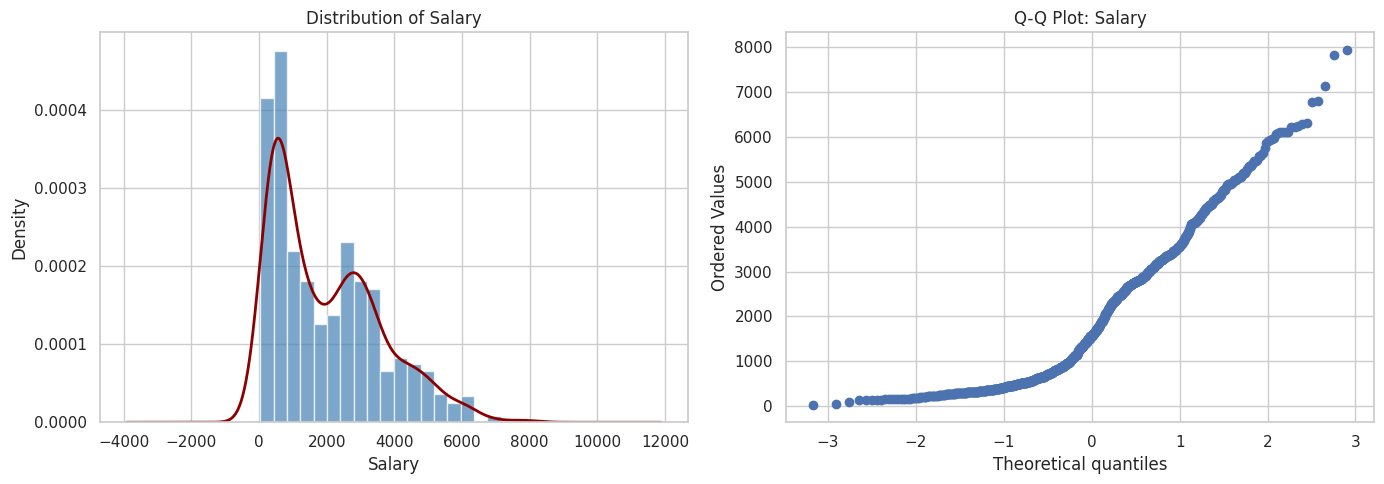

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(df_quality["salary_after_tax_monthly"], bins=20, density=True, alpha=0.7, color="steelblue", edgecolor="white")
df_quality["salary_after_tax_monthly"].plot.kde(ax=axes[0], color="darkred", linewidth=2)
axes[0].set_title("Distribution of Salary")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Density")

# Q-Q plot — points on the line
stats.probplot(df_quality["salary_after_tax_monthly"], plot=axes[1])
axes[1].set_title("Q-Q Plot: Salary")

plt.tight_layout()
plt.show()

## Description

The two charts above describe the distribution of salary and test assumption of normality.


#### Histogram
The histogram shows salary is a bimodal distribution with peaks around 1000 and 3000
The distribution is right-skewed with long tail extending to ~12000


#### Q-Q Plot
The Q-Q plot tests normality assumption by comparing sample quantiles to theoretical normal quantiles.
This plot shows a strong departure from normality given the heavy right tail (upper quantiles deviate upward from reference line). The lower quantiles fit reasonably well, but upper tail shows salary values exceed what normal distribution would predict. This confirms the right skew visible in the histogram.

<br>

**Salary is not normally distributed**. Any parametric tests assuming normality would require transformation or non-parametric alternatives. The bimodality and skew suggest distinct city clusters or the presence of different economic tiers in the dataset.



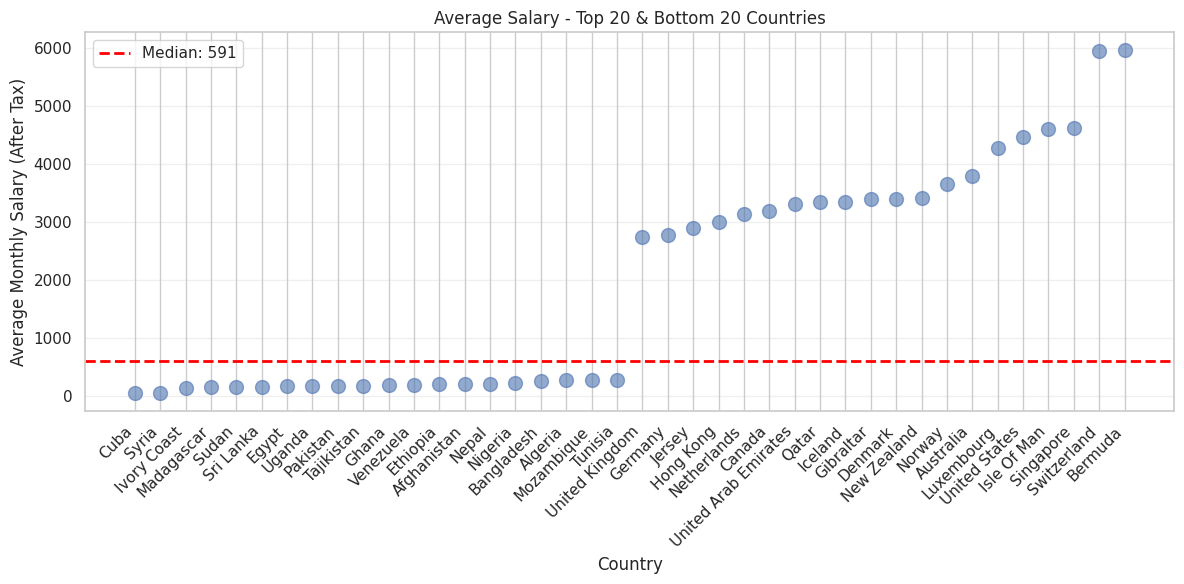

                Avg Salary
country                   
Cuba             35.750000
Syria            50.240000
Ivory Coast     131.960000
Madagascar      142.040000
Sudan           148.570000
...                    ...
United States  4468.144959
Isle Of Man    4608.500000
Singapore      4619.450000
Switzerland    5953.027273
Bermuda        5973.810000

[146 rows x 1 columns]

Highest: 5973.81 (Bermuda)
Lowest: 35.75 (Cuba)


In [ ]:
# Show only extremes (top 20 and bottom 20)
avg_salary_by_country = df_quality.groupby('country')['salary_after_tax_monthly'].mean().sort_values()
extremes = pd.concat([avg_salary_by_country.head(20), avg_salary_by_country.tail(20)])

plt.figure(figsize=(12, 6))
median_salary = avg_salary_by_country.median()

plt.scatter(range(len(extremes)), extremes.values, s=100, alpha=0.6)
plt.axhline(y=median_salary, color='red', linestyle='--', linewidth=2, label=f'Median: {median_salary:.0f}')
plt.xticks(range(len(extremes)), extremes.index, rotation=45, ha='right')
plt.xlabel('Country')
plt.ylabel('Average Monthly Salary (After Tax)')
plt.title('Average Salary - Top 20 & Bottom 20 Countries')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(pd.DataFrame({'Avg Salary': avg_salary_by_country}))
print(f"\nHighest: {avg_salary_by_country.iloc[-1]:.2f} ({avg_salary_by_country.index[-1]})")
print(f"Lowest: {avg_salary_by_country.iloc[0]:.2f} ({avg_salary_by_country.index[0]})")

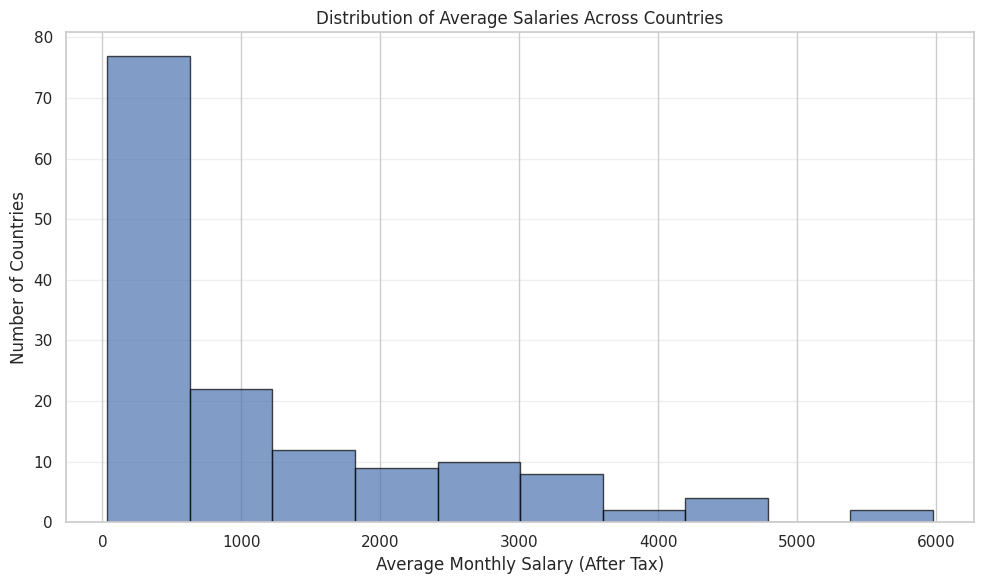

Countries in dataset: 146
               Avg Salary
country                  
Cuba                35.75
Syria               50.24
Ivory Coast        131.96
Madagascar         142.04
Sudan              148.57
...                   ...
United States     4468.14
Isle Of Man       4608.50
Singapore         4619.45
Switzerland       5953.03
Bermuda           5973.81

[146 rows x 1 columns]

Highest: 5973.81 (Bermuda)
Lowest: 35.75 (Cuba)


In [ ]:
# Group by country and calculate average salary
avg_salary_by_country = df_quality.groupby('country')['salary_after_tax_monthly'].mean().round(2).sort_values()

plt.figure(figsize=(10, 6))
plt.hist(avg_salary_by_country.values, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Average Monthly Salary (After Tax)')
plt.ylabel('Number of Countries')
plt.title('Distribution of Average Salaries Across Countries')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Countries in dataset: {len(avg_salary_by_country)}")

# Print summary
print(pd.DataFrame({'Avg Salary': avg_salary_by_country}))
print(f"\nHighest: {avg_salary_by_country.iloc[-1]:.2f} ({avg_salary_by_country.index[-1]})")
print(f"Lowest: {avg_salary_by_country.iloc[0]:.2f} ({avg_salary_by_country.index[0]})")

-----------

##Comparing Different Variables

Is there any correlation between salary, the cost of a 1 bedroom apartment, and the cost of a cappuccino? This seems like a curious question but is more complex to map out than one may think.

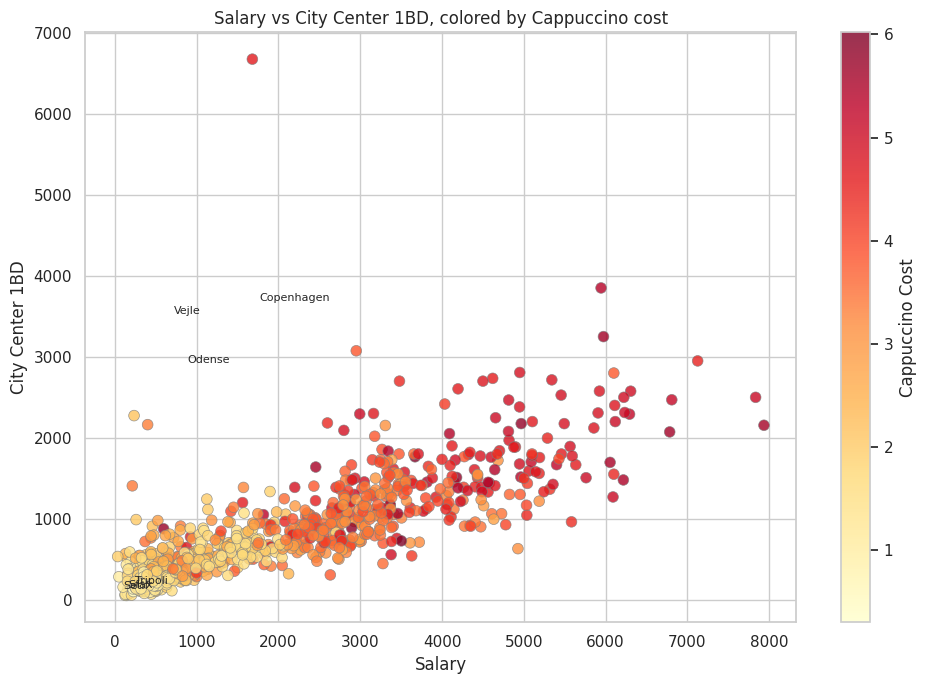

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df_quality["salary_after_tax_monthly"],
    df_quality["apt_1br_city_centre_rent"],
    c=df_quality["cappuccino"],
    cmap="YlOrRd",
    s=60,
    alpha=0.8,
    edgecolors="gray",
    linewidth=0.5
)

# Label a few interesting points
for _, row in df_quality[df_quality["cappuccino"] > 8].iterrows():
    ax.annotate(row["city"], (row["apt_1br_city_centre_rent"], row["salary_after_tax_monthly"]),
                fontsize=8, ha="right", va="bottom")

for _, row in df_quality.nlargest(3, "cappuccino").iterrows():
    ax.annotate(row["city"], (row["apt_1br_city_centre_rent"], row["salary_after_tax_monthly"]),
                fontsize=8, ha="left", va="bottom")

for _, row in df_quality.nsmallest(3, "cappuccino").iterrows():
    ax.annotate(row["city"], (row["apt_1br_city_centre_rent"], row["salary_after_tax_monthly"]),
                fontsize=8, ha="left", va="top")

plt.colorbar(scatter, label="Cappuccino Cost")
ax.set_xlabel("Salary")
ax.set_ylabel("City Center 1BD")
ax.set_title("Salary vs City Center 1BD, colored by Cappuccino cost")
plt.tight_layout()
plt.show()

### Description

The scratterplot above shows positive correlation between salary and rental prices. The color gradient suggests cappuccino cost also correlates positively with both variables (expensive cities have higher salaries, rents, and cappuccino)
The distribution appears heteroskedastic — variance in rental prices increases with salary.

-------

## Going deeper into the data

This dataset has over 50 columns, but which ones are more meaningful when it comes to describing differences between individual cities.

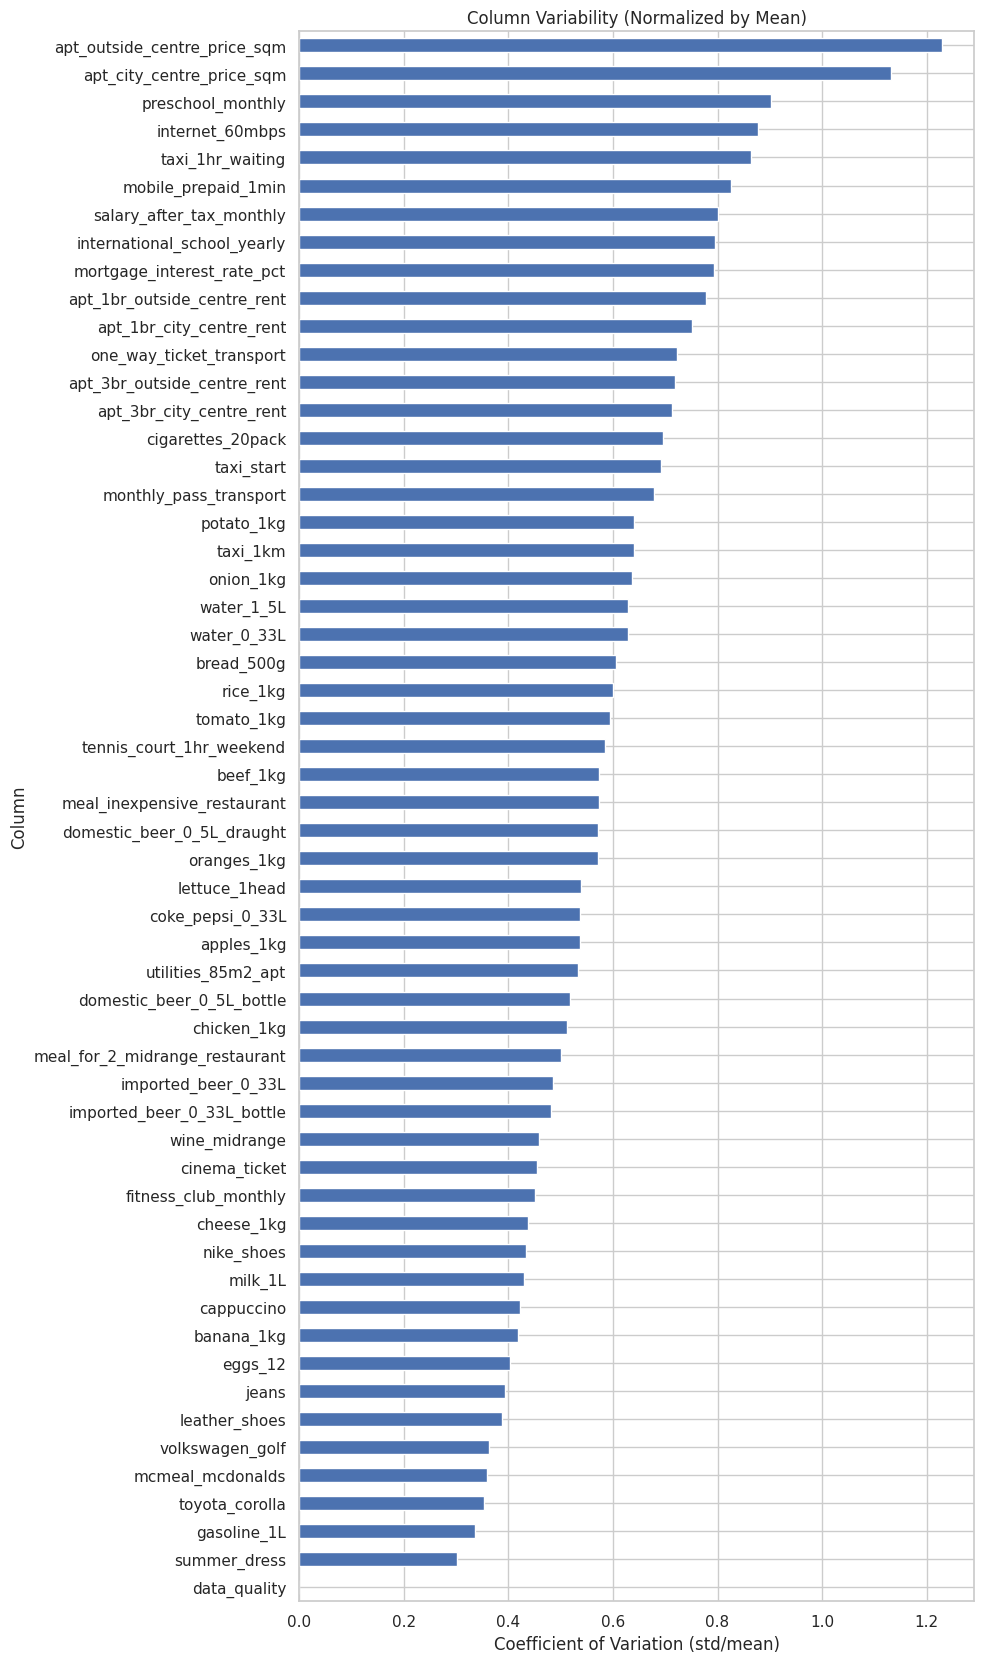

                                Coefficient of Variation
data_quality                                    0.000000
summer_dress                                    0.300828
gasoline_1L                                     0.336897
toyota_corolla                                  0.353935
mcmeal_mcdonalds                                0.359403
volkswagen_golf                                 0.362939
leather_shoes                                   0.387714
jeans                                           0.393980
eggs_12                                         0.402261
banana_1kg                                      0.417583
cappuccino                                      0.422382
milk_1L                                         0.429938
nike_shoes                                      0.433631
cheese_1kg                                      0.437885
fitness_club_monthly                            0.451586
cinema_ticket                                   0.455248
wine_midrange                  

In [ ]:
# Coefficient of Variation: standard deviation / mean
# Provides scale-independent measure of variability (high CV = high spread relative to mean)
numeric_df = df_quality.select_dtypes(include=[np.number])
coefficient_of_variation = (numeric_df.std() / numeric_df.mean().abs()).sort_values()

# Create horizontal bar chart
plt.figure(figsize=(10, max(6, len(coefficient_of_variation) * 0.3)))
coefficient_of_variation.plot(kind='barh')
plt.xlabel('Coefficient of Variation (std/mean)')
plt.ylabel('Column')
plt.title('Column Variability (Normalized by Mean)')
plt.tight_layout()
plt.show()

# Print summary stats
print(pd.DataFrame({'Coefficient of Variation': coefficient_of_variation}))
print(f"Highest variability: {coefficient_of_variation.iloc[-1]:.2f} ({coefficient_of_variation.index[-1]})")
print(f"Lowest variability: {coefficient_of_variation.iloc[0]:.2f} ({coefficient_of_variation.index[0]})")

##Description

Interestingly many columns have very high coefficient of variation (above 0.3), and the highest variance variables are the costs for volkswagen golf, toyota corolla, interational schools yearly tuition, sqm price of apartments in and outside the city center, and monthly salary after tax.

The coefficient of variation indicates which columns have more variability and may provide insight into differences between individual cities. However, low variance columns also signify similarity between different cities, so they provide a different kind of insight.

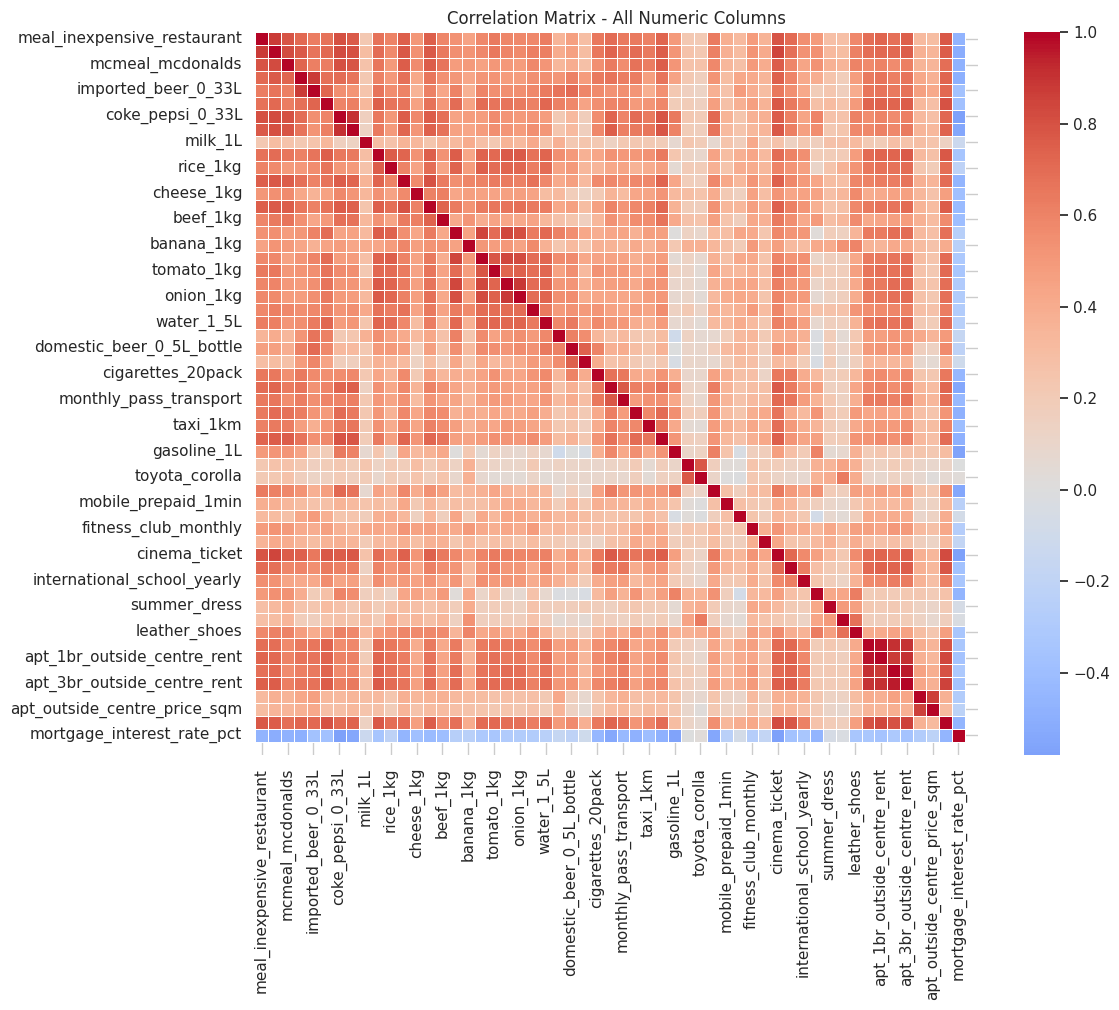




STRONG POSITIVE CORRELATIONS (> 0.8):
  meal_inexpensive_restaurant <-> meal_for_2_midrange_restaurant: 0.88
  meal_inexpensive_restaurant <-> coke_pepsi_0_33L: 0.80
  meal_for_2_midrange_restaurant <-> mcmeal_mcdonalds: 0.82
  meal_for_2_midrange_restaurant <-> coke_pepsi_0_33L: 0.82
  meal_for_2_midrange_restaurant <-> water_0_33L: 0.80
  meal_for_2_midrange_restaurant <-> cinema_ticket: 0.84
  mcmeal_mcdonalds <-> coke_pepsi_0_33L: 0.80
  domestic_beer_0_5L_draught <-> imported_beer_0_33L: 0.87
  coke_pepsi_0_33L <-> water_0_33L: 0.91
  eggs_12 <-> chicken_1kg: 0.80
  apples_1kg <-> oranges_1kg: 0.84
  apples_1kg <-> potato_1kg: 0.83
  apples_1kg <-> onion_1kg: 0.81
  oranges_1kg <-> potato_1kg: 0.83
  oranges_1kg <-> onion_1kg: 0.82
  potato_1kg <-> onion_1kg: 0.88
  cinema_ticket <-> salary_after_tax_monthly: 0.82
  apt_1br_city_centre_rent <-> apt_1br_outside_centre_rent: 0.97
  apt_1br_city_centre_rent <-> apt_3br_city_centre_rent: 0.90
  apt_1br_city_centre_rent <-> apt_3br_

In [ ]:
# Compute correlation matrix for all numeric columns
numeric_columns = df_quality.select_dtypes(include=[np.number])
correlation_matrix = numeric_columns.corr()

# Visualize correlation matrix as heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Set to True to show correlation values in cells
    cmap='coolwarm',  # Red = positive correlation, Blue = negative correlation
    center=0,  # White = no correlation
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix - All Numeric Columns')
plt.tight_layout()
plt.show()

print("")
print("")
print("")
# Print strong positive correlations (> 0.8, excluding self-correlations)
print("STRONG POSITIVE CORRELATIONS (> 0.8):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.8:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")
print("")
# Print strong negative/inverse correlations (< -0.4)
print("WEAK INVERSE CORRELATIONS (< -0.4):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] < -0.4:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")

------

###Querying specific cities

In [ ]:
##query specific city
df_quality[df_quality['city'] == 'New York']

,city,country,meal_inexpensive_restaurant,meal_for_2_midrange_restaurant,mcmeal_mcdonalds,domestic_beer_0_5L_draught,imported_beer_0_33L,cappuccino,coke_pepsi_0_33L,water_0_33L,...,leather_shoes,apt_1br_city_centre_rent,apt_1br_outside_centre_rent,apt_3br_city_centre_rent,apt_3br_outside_centre_rent,apt_city_centre_price_sqm,apt_outside_centre_price_sqm,salary_after_tax_monthly,mortgage_interest_rate_pct,data_quality
21,New York,United States,25.0,100.0,10.0,7.2,10.0,5.38,2.72,2.32,...,145.62,3851.51,2347.1,7146.84,4279.34,14784.44,9531.27,5944.31,5.4,1


In [ ]:
##query specific city and column
df_quality[df_quality['city'] == 'New York']['apt_city_centre_price_sqm']

,apt_city_centre_price_sqm
21,14784.44
